In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\KHAJANAWAZ\Downloads\Streamlit\Titanic-Dataset.csv")

In [3]:
df.shape

(891, 12)

In [4]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [5]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
confusion_matrix,
classification_report
)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
GradientBoostingClassifier
)
from xgboost import XGBClassifier
import joblib

In [7]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch Embarked            Ticket     Fare Cabin  PassengerId  Pclass  \
0      0        S         A/5 21171   7.2500   NaN            1       3   
1      0        C          PC 17599  71.2833   C85            2       1   
2      0        S  STON/O2. 3101282   7.9250   NaN            3       3   
3      0        S            113803  53.1000  C123            4       1   
4      0        S            373450   8.0500   NaN            5       3   

   Survived  
0         0  
1         1  
2         1  
3         1  
4         0  
(8

Survived
0    549
1    342
Name: count, dtype: int64


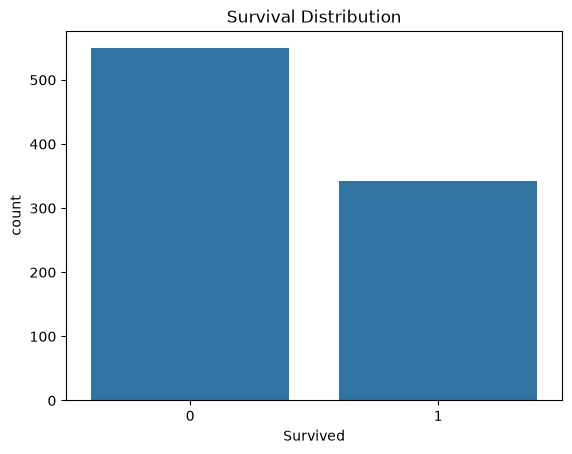

In [8]:
print(df["Survived"].value_counts())
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

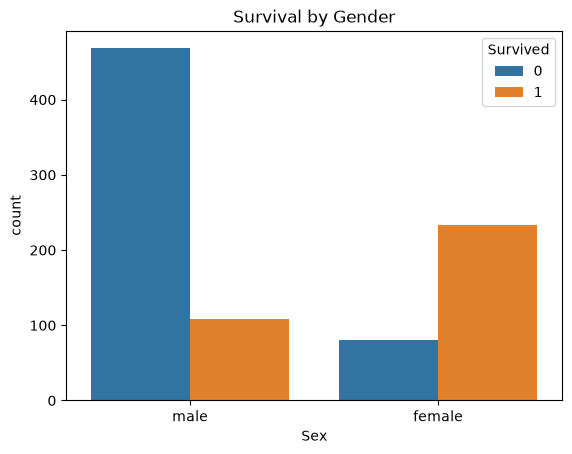

In [9]:
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

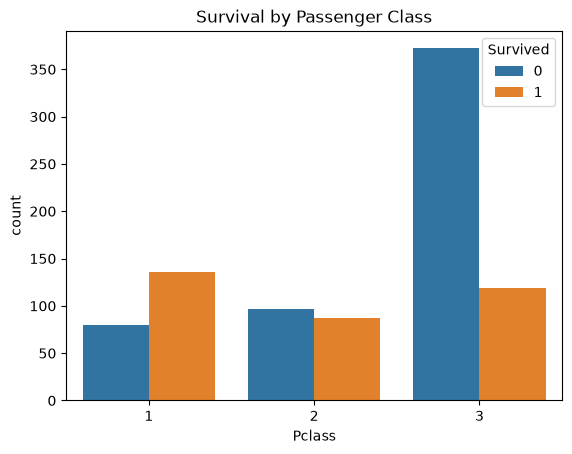

In [10]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.show()

In [11]:
df.columns

Index(['Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Ticket', 'Fare',
       'Cabin', 'PassengerId', 'Pclass', 'Survived'],
      dtype='str')

In [12]:
features = [
"Pclass",
"Sex",
"Age",
"SibSp",
"Parch",
"Fare",
"Embarked"
]

X = df[features]
y = df["Survived"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 7)
Testing data: (179, 7)


In [14]:
numeric_features = ["Pclass","Age","SibSp","Parch","Fare"]
categorical_features = ["Sex","Embarked"]
numeric_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
categorical_transformer = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(
transformers=[("num",numeric_transformer,numeric_features),("cat",categorical_transformer,categorical_features)])

In [15]:
logistic_model = Pipeline(steps=[("preprocessor", preprocessor),("model", LogisticRegression(max_iter=1000))])

In [16]:
decision_tree = Pipeline(steps=[("preprocessor", preprocessor),("model", DecisionTreeClassifier(random_state=42,max_depth=5))])

In [17]:
random_forest = Pipeline(steps=[("preprocessor", preprocessor),("model", RandomForestClassifier(n_estimators=300,random_state=42))])

In [18]:
gradient_boosting = Pipeline(steps=[("preprocessor", preprocessor),("model", GradientBoostingClassifier(random_state=42))])

In [19]:
xgb_model = Pipeline(steps=[("preprocessor", preprocessor),("model", XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=42))])

In [20]:
ml_models = {"Logistic Regression": logistic_model,"Decision Tree": decision_tree,"Random Forest": random_forest,"Gradient Boosting": gradient_boosting,"XGBoost": xgb_model}

In [21]:
ml_results = []
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    ml_results.append({"Model": name,"Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),"Recall": recall_score(y_test, y_pred),"F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)})
ml_results_df = pd.DataFrame(ml_results)
print(ml_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.782123   0.750000  0.652174  0.697674  0.813900


In [22]:
print(ml_results_df.sort_values(by="F1 Score",ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.782123   0.750000  0.652174  0.697674  0.813900
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


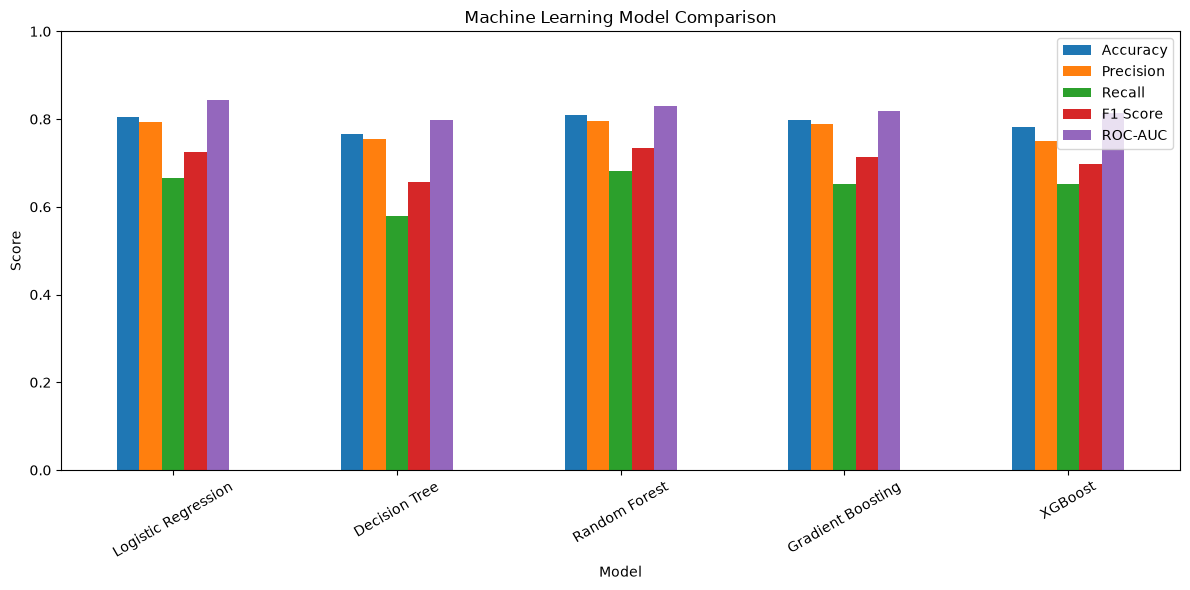

In [23]:
ml_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar",figsize=(12, 6))
plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
dl_numeric = Pipeline([
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])
dl_categorical = Pipeline([
("imputer",
SimpleImputer(strategy="most_frequent")),
("encoder",
OneHotEncoder(handle_unknown="ignore"))
])
dl_preprocessor = ColumnTransformer([
("num", dl_numeric, numeric_features),
("cat", dl_categorical, categorical_features)
])
X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)
X_train_dl = dl_preprocessor.fit_transform(X_train)
X_test_dl = dl_preprocessor.transform(X_test)

print(X_train_dl.shape)
X_test_dl = np.asarray(X_test_dl)
print(X_train_dl.shape)

(712, 10)
(712, 10)


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
ann_model = Sequential([Dense(64,activation="relu",input_shape=(X_train_dl.shape[1],)),Dropout(0.30),Dense(32,activation="relu"),Dropout(0.20),Dense(16,activation="relu"),
Dense(1,activation="sigmoid")])
ann_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
ann_history = ann_model.fit(
X_train_dl,y_train,validation_split=0.20,epochs=50,batch_size=32,verbose=1)

C:\Users\KHAJANAWAZ\AppData\Roaming\Python\Python314\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6467 - loss: 0.6629 - val_accuracy: 0.7413 - val_loss: 0.6215
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7030 - loss: 0.6130 - val_accuracy: 0.7622 - val_loss: 0.5696
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7346 - loss: 0.5612 - val_accuracy: 0.7832 - val_loss: 0.5232
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7627 - loss: 0.5263 - val_accuracy: 0.8042 - val_loss: 0.4896
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7768 - loss: 0.4950 - val_accuracy: 0.7762 - val_loss: 0.4659
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7979 - loss: 0.4535 - val_accuracy: 0.7902 - val_loss: 0.4496
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8155 - loss: 0.4501 - val_accuracy: 0.7902 - val_loss: 0.4412
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8102 - loss: 0.4463 - val_accuracy: 0.8182 - val_loss

In [26]:
ann_prob = ann_model.predict(X_test_dl).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [27]:
ann_results = {"Model": "ANN","Accuracy": accuracy_score(y_test,ann_pred),"Precision": precision_score(y_test,ann_pred),"Recall": recall_score(y_test,ann_pred),
"F1 Score": f1_score(y_test,ann_pred),"ROC-AUC": roc_auc_score(y_test,ann_prob)}
print(ann_results)

{'Model': 'ANN', 'Accuracy': 0.8044692737430168, 'Precision': 0.8269230769230769, 'Recall': 0.6231884057971014, 'F1 Score': 0.7107438016528925, 'ROC-AUC': 0.841897233201581}


In [28]:
X_train_cnn = X_train_dl.reshape(X_train_dl.shape[0],X_train_dl.shape[1],1)
X_test_cnn = X_test_dl.reshape(X_test_dl.shape[0],X_test_dl.shape[1],1)

In [29]:
from tensorflow.keras.layers import (Conv1D,MaxPooling1D,Flatten)
cnn_model = Sequential([
Conv1D(32,kernel_size=3,activation="relu",input_shape=(X_train_cnn.shape[1],1)), MaxPooling1D(pool_size=2),
Conv1D(64,kernel_size=3,activation="relu"),Flatten(),Dense(32,activation="relu"),Dropout(0.30),Dense(1,activation="sigmoid")])
cnn_model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
cnn_history = cnn_model.fit(X_train_cnn,y_train,validation_split=0.20,epochs=50,batch_size=32,verbose=1)

Epoch 1/50


C:\Users\KHAJANAWAZ\AppData\Roaming\Python\Python314\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7012 - loss: 0.6193 - val_accuracy: 0.8112 - val_loss: 0.5544
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7522 - loss: 0.5341 - val_accuracy: 0.8182 - val_loss: 0.4887
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7768 - loss: 0.4951 - val_accuracy: 0.7972 - val_loss: 0.4665
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7838 - loss: 0.4799 - val_accuracy: 0.7972 - val_loss: 0.4613
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7909 - loss: 0.4655 - val_accuracy: 0.7902 - val_loss: 0.4607
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7926 - loss: 0.4497 - val_accuracy: 0.7972 - val_loss: 0.4552
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7961 - loss: 0.4467 - val_accuracy: 0.8042 - val_loss: 0.4573
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8084 - loss: 0.4389 - val_accuracy: 0.7972 - val_loss: 0.4551
Ep

In [30]:
cnn_prob = cnn_model.predict(X_test_cnn).ravel()
cnn_pred = (cnn_prob >= 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [31]:
cnn_results = {"Model": "1D CNN","Accuracy": accuracy_score(y_test,cnn_pred),"Precision": precision_score(y_test,cnn_pred),
               "Recall": recall_score(y_test,cnn_pred),"F1 Score": f1_score(y_test,cnn_pred),"ROC-AUC": roc_auc_score(y_test,cnn_prob)}
print(cnn_results)

{'Model': '1D CNN', 'Accuracy': 0.7653631284916201, 'Precision': 0.7014925373134329, 'Recall': 0.6811594202898551, 'F1 Score': 0.6911764705882353, 'ROC-AUC': 0.8403162055335969}


In [32]:
dl_results_df = pd.DataFrame([ann_results,cnn_results])
all_results = pd.concat([ml_results_df,dl_results_df],ignore_index=True)
print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
4              XGBoost  0.782123   0.750000  0.652174  0.697674  0.813900
5                  ANN  0.804469   0.826923  0.623188  0.710744  0.841897
6               1D CNN  0.765363   0.701493  0.681159  0.691176  0.840316


In [33]:
all_results = all_results.sort_values(by="F1 Score",ascending=False)
print(all_results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
2        Random Forest  0.810056   0.796610  0.681159  0.734375  0.828722
0  Logistic Regression  0.804469   0.793103  0.666667  0.724409  0.843742
3    Gradient Boosting  0.798883   0.789474  0.652174  0.714286  0.817918
5                  ANN  0.804469   0.826923  0.623188  0.710744  0.841897
4              XGBoost  0.782123   0.750000  0.652174  0.697674  0.813900
6               1D CNN  0.765363   0.701493  0.681159  0.691176  0.840316
1        Decision Tree  0.765363   0.754717  0.579710  0.655738  0.797101


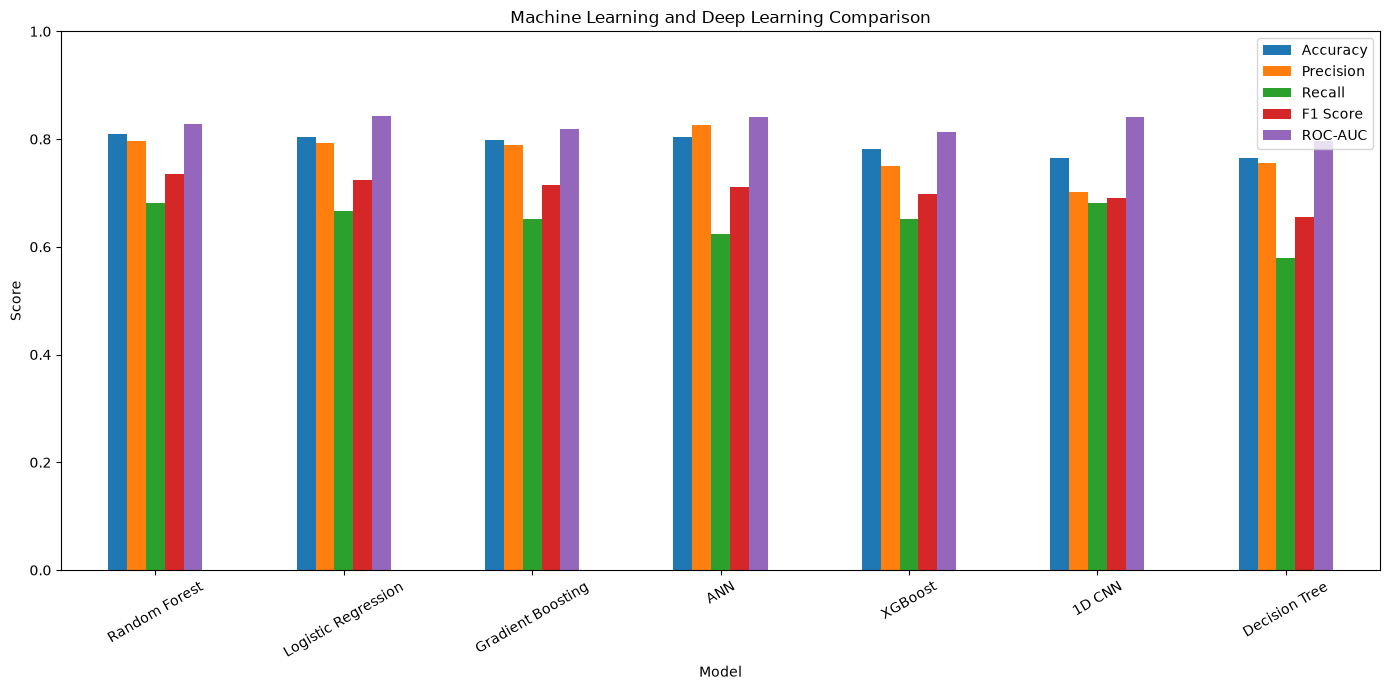

In [34]:
all_results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","ROC-AUC"]].plot(kind="bar",figsize=(14, 7))
plt.title(
"Machine Learning and Deep Learning Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [35]:
best_model_name = all_results.iloc[0]["Model"]
print("Best model based on F1 Score:",best_model_name)

Best model based on F1 Score: Random Forest


In [36]:
best_ml_model = ml_models[best_model_name]
joblib.dump(best_ml_model,"titanic_best_model.pkl")

['titanic_best_model.pkl']